# Experiment 2 — Focused SAELens geometry comparison (128M activations)

Train four SAELens methods on the correlated composed-feature hidden activations from `01_correlated_feature_amplitudes.ipynb`:

- Matryoshka BatchTopK
- Matching Pursuit
- BatchTopK
- TopK

Every method is trained for **128,000,000 activations per seed**, with two seeds and four SAE latents (`f1`–`f4`). The only numerical diagnostics retained are primitive alignment and composition alignment. The primary output is a labeled geometry plot for every method and seed.

Final model checkpoints are saved automatically and loaded on later notebook runs.

## 1. Setup

Device selection reuses `toy_model.default_device()`, the same project utility used by Experiment 1. On this machine it selects Apple MPS. For the two BatchTopK-based architectures, a localized compatibility step keeps SAELens's running threshold in float32 because Apple MPS does not support float64 tensors.

In [1]:
from __future__ import annotations

from collections import OrderedDict
from dataclasses import replace
from itertools import permutations
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F

import sae_lens
from sae_lens import (
    BatchTopKTrainingSAE,
    BatchTopKTrainingSAEConfig,
    MatchingPursuitTrainingSAE,
    MatchingPursuitTrainingSAEConfig,
    MatryoshkaBatchTopKTrainingSAE,
    MatryoshkaBatchTopKTrainingSAEConfig,
    TopKTrainingSAE,
    TopKTrainingSAEConfig,
)
from sae_lens.config import LoggingConfig, SAETrainerConfig
from sae_lens.training.sae_trainer import SAETrainer

from sae import TMSHiddenActivationIterator
from toy_model import (
    FULL_TOY_TRAINING,
    default_device,
    load_toy_model,
    make_correlated_amplitude_model,
    save_toy_model,
    train_toy_model,
)

DEVICE = default_device()
D_SAE = 4
TARGET_K = 2
SEEDS = (0, 1)
TRAINING_SAMPLES = 128_000_000
TRAIN_BATCH_SIZE = 1_024
LEARNING_RATE = 3e-4

CHECKPOINT_ROOT = Path('artifacts/saelens_architecture_comparison_full_128m')
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

assert TRAINING_SAMPLES % TRAIN_BATCH_SIZE == 0
print('SAELens:', sae_lens.__version__)
print('Device:', DEVICE)
print('Activations per run:', f'{TRAINING_SAMPLES:,}')
print('Steps per run:', f'{TRAINING_SAMPLES // TRAIN_BATCH_SIZE:,}')
print('Seeds:', SEEDS)
print('Checkpoint root:', CHECKPOINT_ROOT)

SAELens: 6.47.0
Device: mps
Activations per run: 128,000,000
Steps per run: 125,000
Seeds: (0, 1)
Checkpoint root: artifacts/saelens_architecture_comparison_full_128m


## 2. Load the Experiment 1 toy model

This uses the same trained `toy_model_full.pt` checkpoint as the full correlated-amplitude experiment. If it is missing, the full toy model is trained and saved first.

In [8]:
toy_checkpoint = Path('artifacts/toy_model_full.pt')
model = make_correlated_amplitude_model(FULL_TOY_TRAINING, device=DEVICE)

if toy_checkpoint.exists():
    load_toy_model(model, toy_checkpoint)
    print('Loaded', toy_checkpoint)
else:
    toy_losses = train_toy_model(model, FULL_TOY_TRAINING)
    save_toy_model(model, toy_checkpoint)
    print('Trained and saved', toy_checkpoint)

model.eval()
print('TMS hidden directions:')
print(model.W.detach().cpu())

Loaded artifacts/toy_model_full.pt
TMS hidden directions:
tensor([[ 0.9061,  0.4231],
        [-0.9061, -0.4231],
        [ 0.4231, -0.9061],
        [-0.4231,  0.9061]])


## 3. Configure the four SAE methods

All methods use four decoder vectors and unit-norm decoder initialization. `k=2` matches the intended description of each sample as two active primitive features. Matryoshka uses nested widths `[2, 4]` because the final dictionary must contain exactly `f1`–`f4`. Matching Pursuit may select at most two atoms per input.

In [21]:
common_sae_config = dict(
    d_in=model.cfg.hidden_size,
    d_sae=D_SAE,
    device=str(DEVICE),
    dtype='float32',
    apply_b_dec_to_input=False,
    normalize_activations='none',
    decoder_init_norm=1.0,
)

ARCHITECTURES = OrderedDict({
    'matryoshka_batchtopk': (
        MatryoshkaBatchTopKTrainingSAE,
        MatryoshkaBatchTopKTrainingSAEConfig(
            **common_sae_config,
            k=float(TARGET_K),
            matryoshka_widths=[2, 4],
        ),
    ),
    'matching_pursuit': (
        MatchingPursuitTrainingSAE,
        MatchingPursuitTrainingSAEConfig(
            **common_sae_config,
            residual_threshold=0.01,
            max_iterations=2,
        ),
    ),
    'batchtopk': (
        BatchTopKTrainingSAE,
        BatchTopKTrainingSAEConfig(
            **common_sae_config,
            k=float(TARGET_K),
        ),
    ),
    'topk': (
        TopKTrainingSAE,
        TopKTrainingSAEConfig(
            **common_sae_config,
            k=TARGET_K,
        ),
    ),
})

DISPLAY_NAMES = {
    'matryoshka_batchtopk': 'Matryoshka BatchTopK',
    'matching_pursuit': 'Matching Pursuit',
    'batchtopk': 'BatchTopK',
    'topk': 'TopK',
}

print('Methods:', list(DISPLAY_NAMES.values()))

Methods: ['Matryoshka BatchTopK', 'Matching Pursuit', 'BatchTopK', 'TopK']


## 4. Train or load all eight runs

Each architecture/seed pair receives 128M freshly sampled toy-model hidden activations through `TMSHiddenActivationIterator`, matching Experiment 1's full SAE activation budget.

After training, `cfg.json` and `sae_weights.safetensors` are saved beneath `CHECKPOINT_ROOT/<method>/seed_<n>/`. If both files already exist, the final SAE is loaded and training is skipped. These are **final model checkpoints**; optimizer state is not saved for mid-run resumption.

In [10]:
def make_trainer(sae):
    trainer_config = SAETrainerConfig(
        total_training_samples=TRAINING_SAMPLES,
        train_batch_size_samples=TRAIN_BATCH_SIZE,
        lr=LEARNING_RATE,
        lr_end=LEARNING_RATE,
        lr_scheduler_name='constant',
        lr_warm_up_steps=0,
        lr_decay_steps=0,
        adam_beta1=0.0,
        adam_beta2=0.999,
        device=str(DEVICE),
        n_checkpoints=0,
        checkpoint_path=None,
        save_final_checkpoint=False,
        logger=LoggingConfig(
            log_to_wandb=False,
            eval_every_n_wandb_logs=2**31 - 1,
        ),
        n_batches_for_norm_estimate=1,
    )
    return SAETrainer(
        cfg=trainer_config,
        sae=sae,
        data_provider=TMSHiddenActivationIterator(model, TRAIN_BATCH_SIZE),
    )

def place_sae_on_device(sae):
    # SAELens 6.47 initializes BatchTopK's running threshold as float64.
    # MPS has no float64 support, so retain the statistic in float32 there.
    if DEVICE.type == 'mps' and hasattr(sae, 'topk_threshold'):
        sae.topk_threshold = sae.topk_threshold.float()
    sae.cfg.device = str(DEVICE)
    return sae.to(DEVICE)

def initialize_sae(sae_cls, sae_config):
    is_batchtopk = issubclass(sae_cls, BatchTopKTrainingSAE)
    if DEVICE.type == 'mps' and is_batchtopk:
        # Construct on CPU so SAELens can create its float64 buffer, then
        # cast that one buffer before moving the whole SAE to MPS.
        sae = sae_cls(replace(sae_config, device='cpu'))
    else:
        sae = sae_cls(sae_config)
    return place_sae_on_device(sae)

def load_sae_checkpoint(sae_cls, run_dir):
    is_batchtopk = issubclass(sae_cls, BatchTopKTrainingSAE)
    load_device = (
        'cpu' if DEVICE.type == 'mps' and is_batchtopk else str(DEVICE)
    )
    sae = sae_cls.load_from_disk(
        run_dir, device=load_device, dtype='float32'
    )
    return place_sae_on_device(sae)

def train_or_load(name, sae_cls, sae_config, seed):
    run_dir = CHECKPOINT_ROOT / name / f'seed_{seed}'
    config_path = run_dir / 'cfg.json'
    weights_path = run_dir / 'sae_weights.safetensors'

    if config_path.exists() and weights_path.exists():
        sae = load_sae_checkpoint(sae_cls, run_dir)
        print('Loaded', run_dir)
        return sae

    torch.manual_seed(seed)
    sae = initialize_sae(sae_cls, sae_config)
    sae = make_trainer(sae).fit()
    run_dir.mkdir(parents=True, exist_ok=True)
    sae.save_model(run_dir)
    print('Saved', run_dir)
    return sae

In [5]:
trained_saes = {}
for name, (sae_cls, sae_config) in ARCHITECTURES.items():
    for seed in SEEDS:
        trained_saes[(name, seed)] = train_or_load(
            name, sae_cls, sae_config, seed
        )

print(f'Ready: {len(trained_saes)} trained/loaded SAEs')

Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

Saved artifacts/saelens_architecture_comparison_full_128m/matryoshka_batchtopk/seed_0


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

Saved artifacts/saelens_architecture_comparison_full_128m/matryoshka_batchtopk/seed_1


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

...

Saved artifacts/saelens_architecture_comparison_full_128m/batchtopk/seed_1


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

Saved artifacts/saelens_architecture_comparison_full_128m/topk/seed_0


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

Saved artifacts/saelens_architecture_comparison_full_128m/topk/seed_1
Ready: 8 trained/loaded SAEs


## 5. Primitive and composition alignment

For each SAE, calculate the best one-to-one cosine matching between `f1`–`f4` and either:

- the primitive directions `(x1, x2, y1, y2)`, or
- the composed directions `(x1+y1, x1+y2, x2+y1, x2+y2)`.

In [16]:
def best_matching_cosine(decoder_vectors, target_vectors):
    decoder = F.normalize(decoder_vectors.detach().cpu(), dim=-1)
    targets = F.normalize(target_vectors.detach().cpu(), dim=-1)
    similarity = targets @ decoder.T
    return max(
        sum(
            float(similarity[row, order[row]])
            for row in range(len(targets))
        ) / len(targets)
        for order in permutations(range(decoder.shape[0]), len(targets))
    )

# primitive_vectors = model.W.detach().cpu()
# composition_vectors = torch.stack([
#     primitive_vectors[x] + primitive_vectors[y]
#     for x in range(2)
#     for y in range(2, 4)
# ])

# alignment_results = pd.DataFrame([
#     {
#         'method': name,
#         'seed': seed,
#         'primitive_alignment': best_matching_cosine(
#             sae.W_dec, primitive_vectors
#         ),
#         'composition_alignment': best_matching_cosine(
#             sae.W_dec, composition_vectors
#         ),
#     }
#     for (name, seed), sae in trained_saes.items()
# ])

# alignment_results.to_csv(
#     CHECKPOINT_ROOT / 'alignment_results.csv', index=False
# )
# alignment_results.sort_values(['method', 'seed']).reset_index(drop=True)

## 6. Geometry plots for every method and seed

- Colored solid arrows: true primitive TMS features `x1`, `x2`, `y1`, `y2`.
- Black arrows: learned SAE decoder features `f1`, `f2`, `f3`, `f4`.

The geometry is rotated only for display so that `x1` lies on the positive horizontal axis. All angles and cosine relationships are preserved.

NameError: name 'trained_saes' is not defined

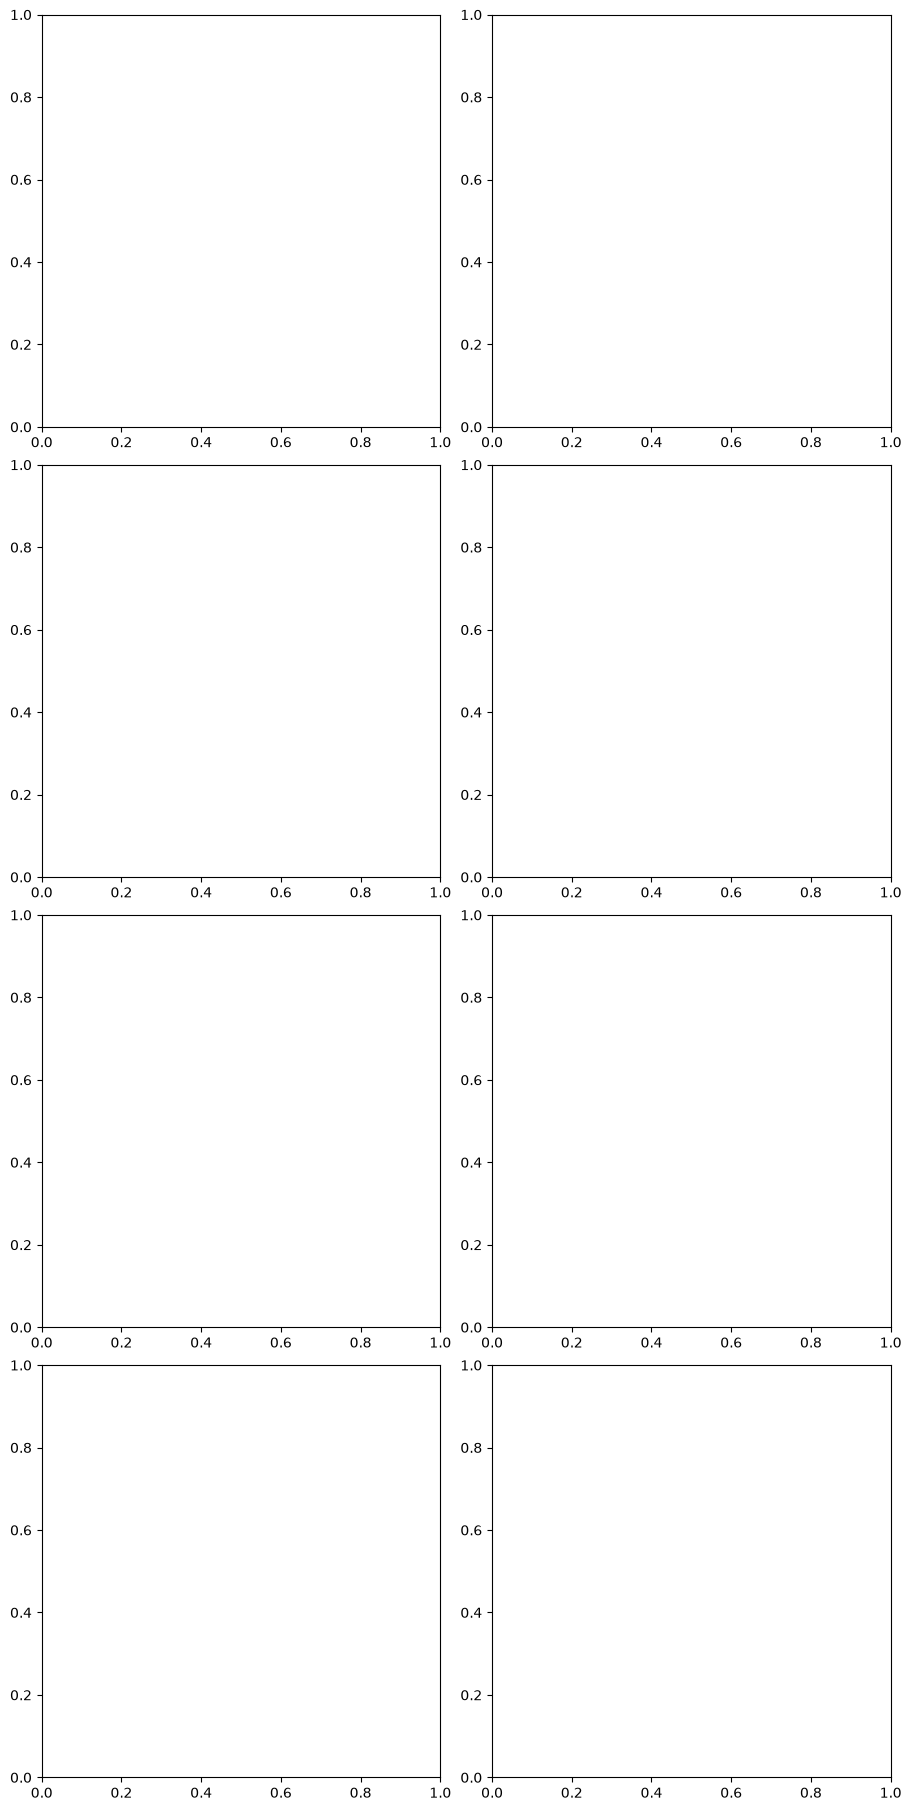

In [23]:
PRIMITIVE_LABELS = ('x1', 'x2', 'y1', 'y2')
PRIMITIVE_COLORS = ('#1b9e77', '#1b9e77', '#d95f02', '#d95f02')

theta = torch.atan2(primitive_vectors[0, 1], primitive_vectors[0, 0])
rotation = torch.tensor([
    [torch.cos(theta), -torch.sin(theta)],
    [torch.sin(theta), torch.cos(theta)],
])
rotated_primitives = primitive_vectors @ rotation

def draw_arrow(ax, vector, *, color, linewidth, linestyle='-', alpha=1.0):
    ax.annotate(
        '',
        xy=(float(vector[0]), float(vector[1])),
        xytext=(0, 0),
        arrowprops={
            'arrowstyle': '->',
            'color': color,
            'lw': linewidth,
            'linestyle': linestyle,
            'alpha': alpha,
        },
    )

def plot_geometry(ax, name, seed):
    sae = trained_saes[(name, seed)]
    rotated_decoders = F.normalize(
        sae.W_dec.detach().cpu(), dim=-1
    ) @ rotation

    for vector, label, color in zip(
        rotated_primitives, PRIMITIVE_LABELS, PRIMITIVE_COLORS
    ):
        draw_arrow(ax, vector, color=color, linewidth=3.0)
        ax.text(
            1.08 * float(vector[0]), 1.08 * float(vector[1]), label,
            color=color, fontsize=10, fontweight='bold',
            ha='center', va='center',
        )

    label_offsets = (-0.07, 0.07, -0.14, 0.14)
    zero_positions = ((0.12, 0), (0, 0.12), (-0.12, 0), (0, -0.12))
    for index, vector in enumerate(rotated_decoders, start=1):
        draw_arrow(ax, vector, color='black', linewidth=1.8)
        perpendicular = torch.tensor([-vector[1], vector[0]])
        if float(vector.norm()) < 1e-8:
            label_position = zero_positions[index - 1]
        else:
            label_position = (
                0.94 * vector
                + label_offsets[index - 1] * perpendicular
            )
        ax.text(
            float(label_position[0]), float(label_position[1]), f'f{index}',
            color='black', fontsize=9, fontweight='bold',
            ha='center', va='center',
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.7},
        )

    metric_row = alignment_results[
        (alignment_results.method == name)
        & (alignment_results.seed == seed)
    ].iloc[0]
    ax.set_title(
        f'{DISPLAY_NAMES[name]} — seed {seed}\n'
        f'primitive={metric_row.primitive_alignment:.3f}\n'
        f'composition={metric_row.composition_alignment:.3f}',
        fontsize=10,
    )
    ax.axhline(0, color='0.82', lw=0.6)
    ax.axvline(0, color='0.82', lw=0.6)
    ax.set(xlim=(-1.25, 1.25), ylim=(-1.25, 1.25), aspect='equal')
    ax.set_xticks(())
    ax.set_yticks(())

fig, axes = plt.subplots(
    len(ARCHITECTURES), len(SEEDS),
    figsize=(9, 4.5 * len(ARCHITECTURES)),
    squeeze=False, constrained_layout=True,
)
for row, name in enumerate(ARCHITECTURES):
    for column, seed in enumerate(SEEDS):
        plot_geometry(axes[row, column], name, seed)

figure_path = CHECKPOINT_ROOT / 'geometry_all_methods_all_seeds.png'
fig.savefig(figure_path, dpi=200, bbox_inches='tight')
print('Saved', figure_path)
plt.show()

geometry_dir = CHECKPOINT_ROOT / 'geometry_by_run'
geometry_dir.mkdir(parents=True, exist_ok=True)
for name in ARCHITECTURES:
    for seed in SEEDS:
        run_figure, run_axis = plt.subplots(figsize=(5, 5.4))
        plot_geometry(run_axis, name, seed)
        run_path = geometry_dir / f'{name}_seed_{seed}.png'
        run_figure.savefig(run_path, dpi=200, bbox_inches='tight')
        plt.close(run_figure)
print('Saved eight individual plots to', geometry_dir)

## Checkpoint behavior

Yes, the notebook saves checkpoints. It saves one final SAELens model per method and seed:

```text
artifacts/saelens_architecture_comparison_full_128m/
├── matryoshka_batchtopk/seed_0/
├── matryoshka_batchtopk/seed_1/
├── matching_pursuit/seed_0/
├── matching_pursuit/seed_1/
├── batchtopk/seed_0/
├── batchtopk/seed_1/
├── topk/seed_0/
└── topk/seed_1/
```

Each directory contains `cfg.json` and `sae_weights.safetensors`. Completed runs are loaded automatically. The notebook additionally saves `alignment_results.csv`, the combined `geometry_all_methods_all_seeds.png`, and eight separate images under `geometry_by_run/`. It does not save optimizer state, so interrupted runs restart from the beginning.

# Experiment 2B — Architecture-specific successive-halving sweeps

This section is appended to the completed baseline experiment above; none of the earlier training, metrics, geometry, or checkpoint documentation is replaced.

The sweep optimizes recovery of the four primitive directions rather than reconstruction alone:

1. Screen ten curated configurations per method for 8M activations across eight paired seeds.
2. Rank configurations by worst-seed primitive margin, then mean primitive margin and primitive alignment.
3. Promote the best two configurations per method to fresh 128M-activation runs across the same eight seeds.
4. Save resumable final-model checkpoints, CSV results, and geometry plots for every promoted configuration and seed.

Here `primitive_margin = primitive_alignment - composition_alignment`. A positive margin is required because primitive alignment alone can remain high for a composed dictionary in two dimensions.

In [11]:
import json

SWEEP_ROOT = Path('artifacts/saelens_architecture_sweeps')
# 7,812 complete batches: the closest whole-batch budget below 8M.
SCREENING_SAMPLES = 7_812 * TRAIN_BATCH_SIZE  # 7,999,488
FINALIST_SAMPLES = 128_000_000
SWEEP_SEEDS = tuple(range(8))
PROMOTE_PER_METHOD = 2
SCREENING_LIMIT_PER_METHOD = None
RUN_SCREENING = True
RUN_FINALISTS = True

SWEEP_ROOT.mkdir(parents=True, exist_ok=True)
assert SCREENING_SAMPLES % TRAIN_BATCH_SIZE == 0
assert FINALIST_SAMPLES % TRAIN_BATCH_SIZE == 0
print('Screening activations/run:', f'{SCREENING_SAMPLES:,}')
print('Screening steps/run:', f'{SCREENING_SAMPLES // TRAIN_BATCH_SIZE:,}')
print('Finalist activations/run:', f'{FINALIST_SAMPLES:,}')
print('Sweep seeds:', SWEEP_SEEDS)
print('Finalists promoted/method:', PROMOTE_PER_METHOD)

Screening activations/run: 7,999,488
Screening steps/run: 7,812
Finalist activations/run: 128,000,000
Sweep seeds: (0, 1, 2, 3, 4, 5, 6, 7)
Finalists promoted/method: 2


## 7. Curated screening designs

The candidates are deliberately not a full Cartesian product. They cover the informative interactions identified in the baseline geometry while keeping the screening stage tractable.

- **Matryoshka BatchTopK:** weaken the problematic width-2 bottleneck and vary activity pressure and initialization.
- **Matching Pursuit:** vary residual stopping, pursuit depth, duplicate-support stopping, and optimization.
- **BatchTopK:** test activity budgets around two, decoder-norm rescaling, initialization, and momentum. `topk_threshold_lr` is not swept because it tracks the exported inference threshold rather than selecting training activations.
- **TopK:** test the seed-sensitive interaction among `k`, initialization, norm rescaling, learning-rate schedule, and momentum.

The `k=1` BatchTopK and TopK candidates are negative controls expected to favor composed directions.

In [12]:
SCREENING_CONFIGS = {
    'matryoshka_batchtopk': [
        {'widths': [2, 4], 'k': 2.0, 'init': 1.0, 'lr': 3e-4, 'scheduler': 'constant'},
        {'widths': [3, 4], 'k': 2.0, 'init': 1.0, 'lr': 3e-4, 'scheduler': 'constant'},
        {'widths': [3, 4], 'k': 2.0, 'init': 0.1, 'lr': 3e-4, 'scheduler': 'constant'},
        {'widths': [3, 4], 'k': 2.0, 'init': 0.3, 'lr': 1e-4, 'scheduler': 'cosineannealing'},
        {'widths': [3, 4], 'k': 2.25, 'init': 0.3, 'lr': 3e-4, 'scheduler': 'cosineannealing'},
        {'widths': [3, 4], 'k': 2.5, 'init': 0.1, 'lr': 1e-4, 'scheduler': 'cosineannealing'},
        {'widths': [2, 3, 4], 'k': 2.0, 'init': 0.1, 'lr': 1e-4, 'scheduler': 'cosineannealing'},
        {'widths': [2, 3, 4], 'k': 2.25, 'init': 0.3, 'lr': 3e-4, 'scheduler': 'cosineannealing'},
        {'widths': [4], 'k': 2.0, 'init': 0.1, 'lr': 1e-4, 'scheduler': 'cosineannealing'},
        {'widths': [4], 'k': 2.5, 'init': 0.3, 'lr': 3e-4, 'scheduler': 'cosineannealing'},
    ],
    'matching_pursuit': [
        {'threshold': 1e-2, 'iterations': 2, 'stop_duplicate': True, 'lr': 3e-4, 'scheduler': 'constant'},
        {'threshold': 0.0, 'iterations': 3, 'stop_duplicate': False, 'lr': 1e-4, 'scheduler': 'cosineannealing'},
        {'threshold': 1e-4, 'iterations': 3, 'stop_duplicate': True, 'lr': 1e-4, 'scheduler': 'cosineannealing'},
        {'threshold': 1e-4, 'iterations': 4, 'stop_duplicate': False, 'lr': 1e-4, 'scheduler': 'cosineannealing'},
        {'threshold': 1e-3, 'iterations': 3, 'stop_duplicate': True, 'lr': 3e-4, 'scheduler': 'constant'},
        {'threshold': 1e-3, 'iterations': 4, 'stop_duplicate': False, 'lr': 3e-4, 'scheduler': 'cosineannealing'},
        {'threshold': 1e-2, 'iterations': 3, 'stop_duplicate': True, 'lr': 1e-4, 'scheduler': 'cosineannealing'},
        {'threshold': 1e-2, 'iterations': 4, 'stop_duplicate': False, 'lr': 3e-4, 'scheduler': 'cosineannealing'},
        {'threshold': 5e-2, 'iterations': 3, 'stop_duplicate': True, 'lr': 1e-4, 'scheduler': 'constant'},
        {'threshold': 0.0, 'iterations': 4, 'stop_duplicate': True, 'lr': 3e-5, 'scheduler': 'cosineannealing'},
    ],
    'batchtopk': [
        {'k': 2.0, 'rescale': True, 'init': 1.0, 'lr': 3e-4, 'scheduler': 'constant', 'beta1': 0.0},
        {'k': 1.0, 'rescale': True, 'init': 1.0, 'lr': 3e-4, 'scheduler': 'constant', 'beta1': 0.0},
        {'k': 1.5, 'rescale': True, 'init': 0.1, 'lr': 1e-4, 'scheduler': 'cosineannealing', 'beta1': 0.0},
        {'k': 1.75, 'rescale': False, 'init': 0.3, 'lr': 3e-4, 'scheduler': 'cosineannealing', 'beta1': 0.0},
        {'k': 2.0, 'rescale': True, 'init': 0.1, 'lr': 1e-4, 'scheduler': 'cosineannealing', 'beta1': 0.0},
        {'k': 2.0, 'rescale': False, 'init': 0.1, 'lr': 3e-4, 'scheduler': 'constant', 'beta1': 0.0},
        {'k': 2.25, 'rescale': True, 'init': 0.3, 'lr': 1e-4, 'scheduler': 'cosineannealing', 'beta1': 0.0},
        {'k': 2.5, 'rescale': True, 'init': 0.1, 'lr': 3e-4, 'scheduler': 'cosineannealing', 'beta1': 0.9},
        {'k': 2.5, 'rescale': False, 'init': 1.0, 'lr': 1e-4, 'scheduler': 'constant', 'beta1': 0.0},
        {'k': 3.0, 'rescale': True, 'init': 0.3, 'lr': 1e-3, 'scheduler': 'cosineannealing', 'beta1': 0.9},
    ],
    'topk': [
        {'k': 2, 'rescale': True, 'init': 1.0, 'lr': 3e-4, 'scheduler': 'constant', 'beta1': 0.0},
        {'k': 1, 'rescale': True, 'init': 1.0, 'lr': 3e-4, 'scheduler': 'constant', 'beta1': 0.0},
        {'k': 2, 'rescale': True, 'init': 0.1, 'lr': 1e-4, 'scheduler': 'cosineannealing', 'beta1': 0.0},
        {'k': 2, 'rescale': True, 'init': 0.3, 'lr': 3e-4, 'scheduler': 'cosineannealing', 'beta1': 0.0},
        {'k': 2, 'rescale': True, 'init': 1.0, 'lr': 1e-3, 'scheduler': 'cosineannealing', 'beta1': 0.0},
        {'k': 2, 'rescale': False, 'init': 0.1, 'lr': 3e-4, 'scheduler': 'constant', 'beta1': 0.0},
        {'k': 2, 'rescale': False, 'init': 0.3, 'lr': 1e-4, 'scheduler': 'cosineannealing', 'beta1': 0.9},
        {'k': 3, 'rescale': True, 'init': 0.1, 'lr': 1e-4, 'scheduler': 'cosineannealing', 'beta1': 0.0},
        {'k': 3, 'rescale': True, 'init': 0.3, 'lr': 3e-4, 'scheduler': 'cosineannealing', 'beta1': 0.9},
        {'k': 3, 'rescale': False, 'init': 1.0, 'lr': 1e-3, 'scheduler': 'cosineannealing', 'beta1': 0.9},
    ],
}

if SCREENING_LIMIT_PER_METHOD is not None:
    SCREENING_CONFIGS = {
        method: configs[:SCREENING_LIMIT_PER_METHOD]
        for method, configs in SCREENING_CONFIGS.items()
    }

pd.DataFrame([
    {
        'method': method,
        'config_id': f'c{index:02d}',
        'parameters': json.dumps(params, sort_keys=True),
    }
    for method, configs in SCREENING_CONFIGS.items()
    for index, params in enumerate(configs)
]).to_csv(SWEEP_ROOT / 'screening_manifest.csv', index=False)

print({method: len(configs) for method, configs in SCREENING_CONFIGS.items()})

{'matryoshka_batchtopk': 10, 'matching_pursuit': 10, 'batchtopk': 10, 'topk': 10}


## 8. Resumable sweep training

Every method/configuration/seed run is saved immediately after it completes. Re-running these cells loads completed final-model checkpoints and skips their training. As in the baseline experiment, optimizer state is not stored, so only the currently interrupted run—not completed runs—must restart.

In [13]:
def build_sweep_sae(method, params):
    common = dict(
        d_in=model.cfg.hidden_size,
        d_sae=D_SAE,
        device=str(DEVICE),
        dtype='float32',
        apply_b_dec_to_input=False,
        normalize_activations='none',
        decoder_init_norm=params.get('init', 1.0),
    )
    if method == 'matryoshka_batchtopk':
        return (
            MatryoshkaBatchTopKTrainingSAE,
            MatryoshkaBatchTopKTrainingSAEConfig(
                **common, k=float(params['k']),
                matryoshka_widths=list(params['widths']),
            ),
        )
    if method == 'matching_pursuit':
        return (
            MatchingPursuitTrainingSAE,
            MatchingPursuitTrainingSAEConfig(
                **common,
                residual_threshold=params['threshold'],
                max_iterations=params['iterations'],
                stop_on_duplicate_support=params['stop_duplicate'],
            ),
        )
    if method == 'batchtopk':
        return (
            BatchTopKTrainingSAE,
            BatchTopKTrainingSAEConfig(
                **common, k=float(params['k']),
                rescale_acts_by_decoder_norm=params['rescale'],
            ),
        )
    if method == 'topk':
        return (
            TopKTrainingSAE,
            TopKTrainingSAEConfig(
                **common, k=int(params['k']),
                rescale_acts_by_decoder_norm=params['rescale'],
            ),
        )
    raise ValueError(f'Unknown method: {method}')

def make_sweep_trainer(sae, *, total_samples, params):
    scheduler = params['scheduler']
    learning_rate = params['lr']
    trainer_config = SAETrainerConfig(
        total_training_samples=total_samples,
        train_batch_size_samples=TRAIN_BATCH_SIZE,
        lr=learning_rate,
        lr_end=(learning_rate / 100 if scheduler == 'cosineannealing' else learning_rate),
        lr_scheduler_name=scheduler,
        lr_warm_up_steps=0,
        lr_decay_steps=0,
        adam_beta1=params.get('beta1', 0.0),
        adam_beta2=0.999,
        device=str(DEVICE),
        n_checkpoints=0,
        checkpoint_path=None,
        save_final_checkpoint=False,
        logger=LoggingConfig(
            log_to_wandb=False,
            eval_every_n_wandb_logs=2**31 - 1,
        ),
        n_batches_for_norm_estimate=1,
    )
    return SAETrainer(
        cfg=trainer_config, sae=sae,
        data_provider=TMSHiddenActivationIterator(model, TRAIN_BATCH_SIZE),
    )

def train_or_load_sweep(method, config_id, params, seed, total_samples, stage):
    run_dir = SWEEP_ROOT / stage / method / config_id / f'seed_{seed}'
    config_path = run_dir / 'cfg.json'
    weights_path = run_dir / 'sae_weights.safetensors'
    sae_cls, sae_config = build_sweep_sae(method, params)
    if config_path.exists() and weights_path.exists():
        print('Loaded', run_dir)
        return load_sae_checkpoint(sae_cls, run_dir)

    torch.manual_seed(seed)
    sae = initialize_sae(sae_cls, sae_config)
    sae = make_sweep_trainer(
        sae, total_samples=total_samples, params=params
    ).fit()
    run_dir.mkdir(parents=True, exist_ok=True)
    sae.save_model(run_dir)
    print('Saved', run_dir)
    return sae

def run_sweep_stage(configs_by_method, *, total_samples, stage):
    rows = []
    results_path = SWEEP_ROOT / stage / 'alignment_results.csv'
    results_path.parent.mkdir(parents=True, exist_ok=True)
    for method, configs in configs_by_method.items():
        for index, params_with_source in enumerate(configs):
            params = {
                key: value for key, value in params_with_source.items()
                if key != 'source_config_id'
            }
            config_id = params_with_source.get(
                'source_config_id', f'c{index:02d}'
            )
            for seed in SWEEP_SEEDS:
                print(stage, method, config_id, 'seed', seed)
                sae = train_or_load_sweep(
                    method, config_id, params, seed, total_samples, stage
                )
                primitive = best_matching_cosine(sae.W_dec, primitive_vectors)
                composition = best_matching_cosine(
                    sae.W_dec, composition_vectors
                )
                rows.append({
                    'stage': stage, 'method': method,
                    'config_id': config_id, 'seed': seed,
                    'primitive_alignment': primitive,
                    'composition_alignment': composition,
                    'primitive_margin': primitive - composition,
                    'parameters': json.dumps(params, sort_keys=True),
                })
                pd.DataFrame(rows).to_csv(results_path, index=False)
                del sae
                if DEVICE.type == 'mps':
                    torch.mps.empty_cache()
    return pd.DataFrame(rows)

def summarize_sweep(results):
    summary = (
        results.groupby(
            ['method', 'config_id', 'parameters'], as_index=False
        ).agg(
            primitive_mean=('primitive_alignment', 'mean'),
            primitive_worst=('primitive_alignment', 'min'),
            primitive_std=('primitive_alignment', 'std'),
            composition_mean=('composition_alignment', 'mean'),
            margin_mean=('primitive_margin', 'mean'),
            margin_worst=('primitive_margin', 'min'),
        )
    )
    summary = summary.sort_values(
        ['method', 'margin_worst', 'margin_mean', 'primitive_mean'],
        ascending=[True, False, False, False],
    ).reset_index(drop=True)
    summary['rank'] = summary.groupby('method').cumcount() + 1
    return summary


In [17]:
screening_path = SWEEP_ROOT / 'screen_8m' / 'alignment_results.csv'
if RUN_SCREENING:
    screening_results = run_sweep_stage(
        SCREENING_CONFIGS, total_samples=SCREENING_SAMPLES,
        stage='screen_8m',
    )
elif screening_path.exists():
    screening_results = pd.read_csv(screening_path)
else:
    raise FileNotFoundError('Run screening or provide screening results first')

screening_summary = summarize_sweep(screening_results)
screening_summary.to_csv(
    SWEEP_ROOT / 'screen_8m' / 'configuration_summary.csv', index=False
)
screening_summary

screen_8m matryoshka_batchtopk c00 seed 0
Loaded artifacts/saelens_architecture_sweeps/screen_8m/matryoshka_batchtopk/c00/seed_0
screen_8m matryoshka_batchtopk c00 seed 1


Training SAE:   0%|          | 0/7999488 [00:00<?, ?it/s]

Saved artifacts/saelens_architecture_sweeps/screen_8m/matryoshka_batchtopk/c00/seed_1
screen_8m matryoshka_batchtopk c00 seed 2


Training SAE:   0%|          | 0/7999488 [00:00<?, ?it/s]

Saved artifacts/saelens_architecture_sweeps/screen_8m/matryoshka_batchtopk/c00/seed_2
screen_8m matryoshka_batchtopk c00 seed 3


...

Training SAE:   0%|          | 0/7999488 [00:00<?, ?it/s]

Saved artifacts/saelens_architecture_sweeps/screen_8m/topk/c09/seed_6
screen_8m topk c09 seed 7


Training SAE:   0%|          | 0/7999488 [00:00<?, ?it/s]

Saved artifacts/saelens_architecture_sweeps/screen_8m/topk/c09/seed_7


,method,config_id,parameters,primitive_mean,primitive_worst,primitive_std,composition_mean,margin_mean,margin_worst,rank
0,batchtopk,c04,"{""beta1"": 0.0, ""init"": 0.1, ""k"": 2.0, ""lr"": 0....",0.645217,0.408765,0.151767,0.642756,0.002460,-0.120542,1
1,batchtopk,c06,"{""beta1"": 0.0, ""init"": 0.3, ""k"": 2.25, ""lr"": 0...",0.758691,0.628371,0.106989,0.765684,-0.006993,-0.124366,2
2,batchtopk,c09,"{""beta1"": 0.9, ""init"": 0.3, ""k"": 3.0, ""lr"": 0....",0.818225,0.596959,0.140686,0.838801,-0.020576,-0.132168,3
3,batchtopk,c02,"{""beta1"": 0.0, ""init"": 0.1, ""k"": 1.5, ""lr"": 0....",0.687907,0.616038,0.110186,0.699907,-0.012000,-0.134616,4
4,batchtopk,c08,"{""beta1"": 0.0, ""init"": 1.0, ""k"": 2.5, ""lr"": 0....",0.746969,0.643341,0.100555,0.742145,0.004823,-0.141989,5
5,batchtopk,c00,"{""beta1"": 0.0, ""init"": 1.0, ""k"": 2.0, ""lr"": 0....",0.760512,0.675528,0.082172,0.777656,-0.017143,-0.187218,6
6,batchtopk,c07,"{""beta1"": 0.9, ""init"": 0.1, ""k"": 2.5, ""lr"": 0....",0.778317,0.494414,0.161632,0.807251,-0.028934,-0.189975,7
7,batchtopk,c03,"{""beta1"": 0.0, ""init"": 0.3, ""k"": 1.75, ""lr"": 0...",0.822975,0.665177,0.089855,0.854925,-0.031950,-0.190942,8
8,batchtopk,c05,"{""beta1"": 0.0, ""init"": 0.1, ""k"": 2.0, ""lr"": 0....",0.786863,0.595877,0.117489,0.837738,-0.050875,-0.227473,9
9,batchtopk,c01,"{""beta1"": 0.0, ""init"": 1.0, ""k"": 1.0, ""lr"": 0....",0.686303,0.576349,0.076836,0.717284,-0.030981,-0.292391,10


## 9. Promote the most seed-stable configurations

Promotion is determined by the worst primitive margin across the eight seeds. This intentionally rejects configurations that occasionally find primitives but frequently fall into the composed basin. Mean margin and mean primitive alignment break ties.

In [18]:
promoted_summary = screening_summary[
    screening_summary['rank'] <= PROMOTE_PER_METHOD
].copy()

PROMOTED_CONFIGS = {method: [] for method in SCREENING_CONFIGS}
for row in promoted_summary.itertuples(index=False):
    source_index = int(row.config_id.removeprefix('c'))
    promoted = dict(SCREENING_CONFIGS[row.method][source_index])
    promoted['source_config_id'] = row.config_id
    PROMOTED_CONFIGS[row.method].append(promoted)

with (SWEEP_ROOT / 'promoted_configs.json').open('w') as handle:
    json.dump(PROMOTED_CONFIGS, handle, indent=2)

promoted_summary[[
    'method', 'config_id', 'rank', 'margin_worst', 'margin_mean',
    'primitive_mean', 'composition_mean', 'parameters',
]]

,method,config_id,rank,margin_worst,margin_mean,primitive_mean,composition_mean,parameters
0,batchtopk,c04,1,-0.120542,0.002460,0.645217,0.642756,"{""beta1"": 0.0, ""init"": 0.1, ""k"": 2.0, ""lr"": 0...."
1,batchtopk,c06,2,-0.124366,-0.006993,0.758691,0.765684,"{""beta1"": 0.0, ""init"": 0.3, ""k"": 2.25, ""lr"": 0..."
10,matching_pursuit,c05,1,-0.205265,0.048219,0.821908,0.773689,"{""iterations"": 4, ""lr"": 0.0003, ""scheduler"": ""..."
11,matching_pursuit,c09,2,-0.214089,0.031221,0.708133,0.676912,"{""iterations"": 4, ""lr"": 3e-05, ""scheduler"": ""c..."
20,matryoshka_batchtopk,c08,1,-0.120542,0.002460,0.645217,0.642756,"{""init"": 0.1, ""k"": 2.0, ""lr"": 0.0001, ""schedul..."
21,matryoshka_batchtopk,c03,2,-0.138014,-0.012559,0.746070,0.758630,"{""init"": 0.3, ""k"": 2.0, ""lr"": 0.0001, ""schedul..."
30,topk,c05,1,0.044673,0.111578,0.900277,0.788700,"{""beta1"": 0.0, ""init"": 0.1, ""k"": 2, ""lr"": 0.00..."
31,topk,c02,2,-0.126070,0.106798,0.854357,0.747559,"{""beta1"": 0.0, ""init"": 0.1, ""k"": 2, ""lr"": 0.00..."


In [19]:
finalist_path = SWEEP_ROOT / 'final_128m' / 'alignment_results.csv'
if RUN_FINALISTS:
    finalist_results = run_sweep_stage(
        PROMOTED_CONFIGS, total_samples=FINALIST_SAMPLES,
        stage='final_128m',
    )
elif finalist_path.exists():
    finalist_results = pd.read_csv(finalist_path)
else:
    raise FileNotFoundError('Run finalists or provide finalist results first')

finalist_summary = summarize_sweep(finalist_results)
finalist_summary.to_csv(
    SWEEP_ROOT / 'final_128m' / 'configuration_summary.csv', index=False
)
finalist_summary

final_128m matryoshka_batchtopk c08 seed 0


/opt/anaconda3/envs/sae-composed-features/lib/python3.12/site-packages/sae_lens/saes/matryoshka_batchtopk_sae.py:220: UserWarning: WARNING: You have only set one matryoshka level. This is equivalent to using a standard BatchTopK SAE and is likely not what you want.
  warnings.warn(


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

Saved artifacts/saelens_architecture_sweeps/final_128m/matryoshka_batchtopk/c08/seed_0
final_128m matryoshka_batchtopk c08 seed 1


/opt/anaconda3/envs/sae-composed-features/lib/python3.12/site-packages/sae_lens/saes/matryoshka_batchtopk_sae.py:220: UserWarning: WARNING: You have only set one matryoshka level. This is equivalent to using a standard BatchTopK SAE and is likely not what you want.
  warnings.warn(


...

Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

Saved artifacts/saelens_architecture_sweeps/final_128m/topk/c02/seed_6
final_128m topk c02 seed 7


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

Saved artifacts/saelens_architecture_sweeps/final_128m/topk/c02/seed_7


,method,config_id,parameters,primitive_mean,primitive_worst,primitive_std,composition_mean,margin_mean,margin_worst,rank
0,batchtopk,c06,"{""beta1"": 0.0, ""init"": 0.3, ""k"": 2.25, ""lr"": 0...",0.753074,0.573790,0.120612,0.808609,-0.055534,-0.230660,1
1,batchtopk,c04,"{""beta1"": 0.0, ""init"": 0.1, ""k"": 2.0, ""lr"": 0....",0.786577,0.610362,0.118084,0.839762,-0.053185,-0.243900,2
2,matching_pursuit,c05,"{""iterations"": 4, ""lr"": 0.0003, ""scheduler"": ""...",0.845338,0.724016,0.081448,0.791205,0.054134,-0.211550,1
3,matching_pursuit,c09,"{""iterations"": 4, ""lr"": 3e-05, ""scheduler"": ""c...",0.869277,0.715763,0.083320,0.806705,0.062572,-0.218603,2
4,matryoshka_batchtopk,c03,"{""init"": 0.3, ""k"": 2.0, ""lr"": 0.0001, ""schedul...",0.769424,0.593567,0.109628,0.815767,-0.046342,-0.232082,1
5,matryoshka_batchtopk,c08,"{""init"": 0.1, ""k"": 2.0, ""lr"": 0.0001, ""schedul...",0.786577,0.610362,0.118084,0.839762,-0.053185,-0.243900,2
6,topk,c05,"{""beta1"": 0.0, ""init"": 0.1, ""k"": 2, ""lr"": 0.00...",0.897219,0.739044,0.106690,0.788882,0.108337,0.051010,1
7,topk,c02,"{""beta1"": 0.0, ""init"": 0.1, ""k"": 2, ""lr"": 0.00...",0.884475,0.729311,0.123791,0.767264,0.117211,-0.004535,2


## 10. Finalist geometry

The plots retain only the true primitive features and learned SAE features. One grid is saved per method, and a separate full-size image is saved for every promoted configuration and seed.

Saved artifacts/saelens_architecture_sweeps/final_128m/geometry/matryoshka_batchtopk_finalists_all_seeds.png


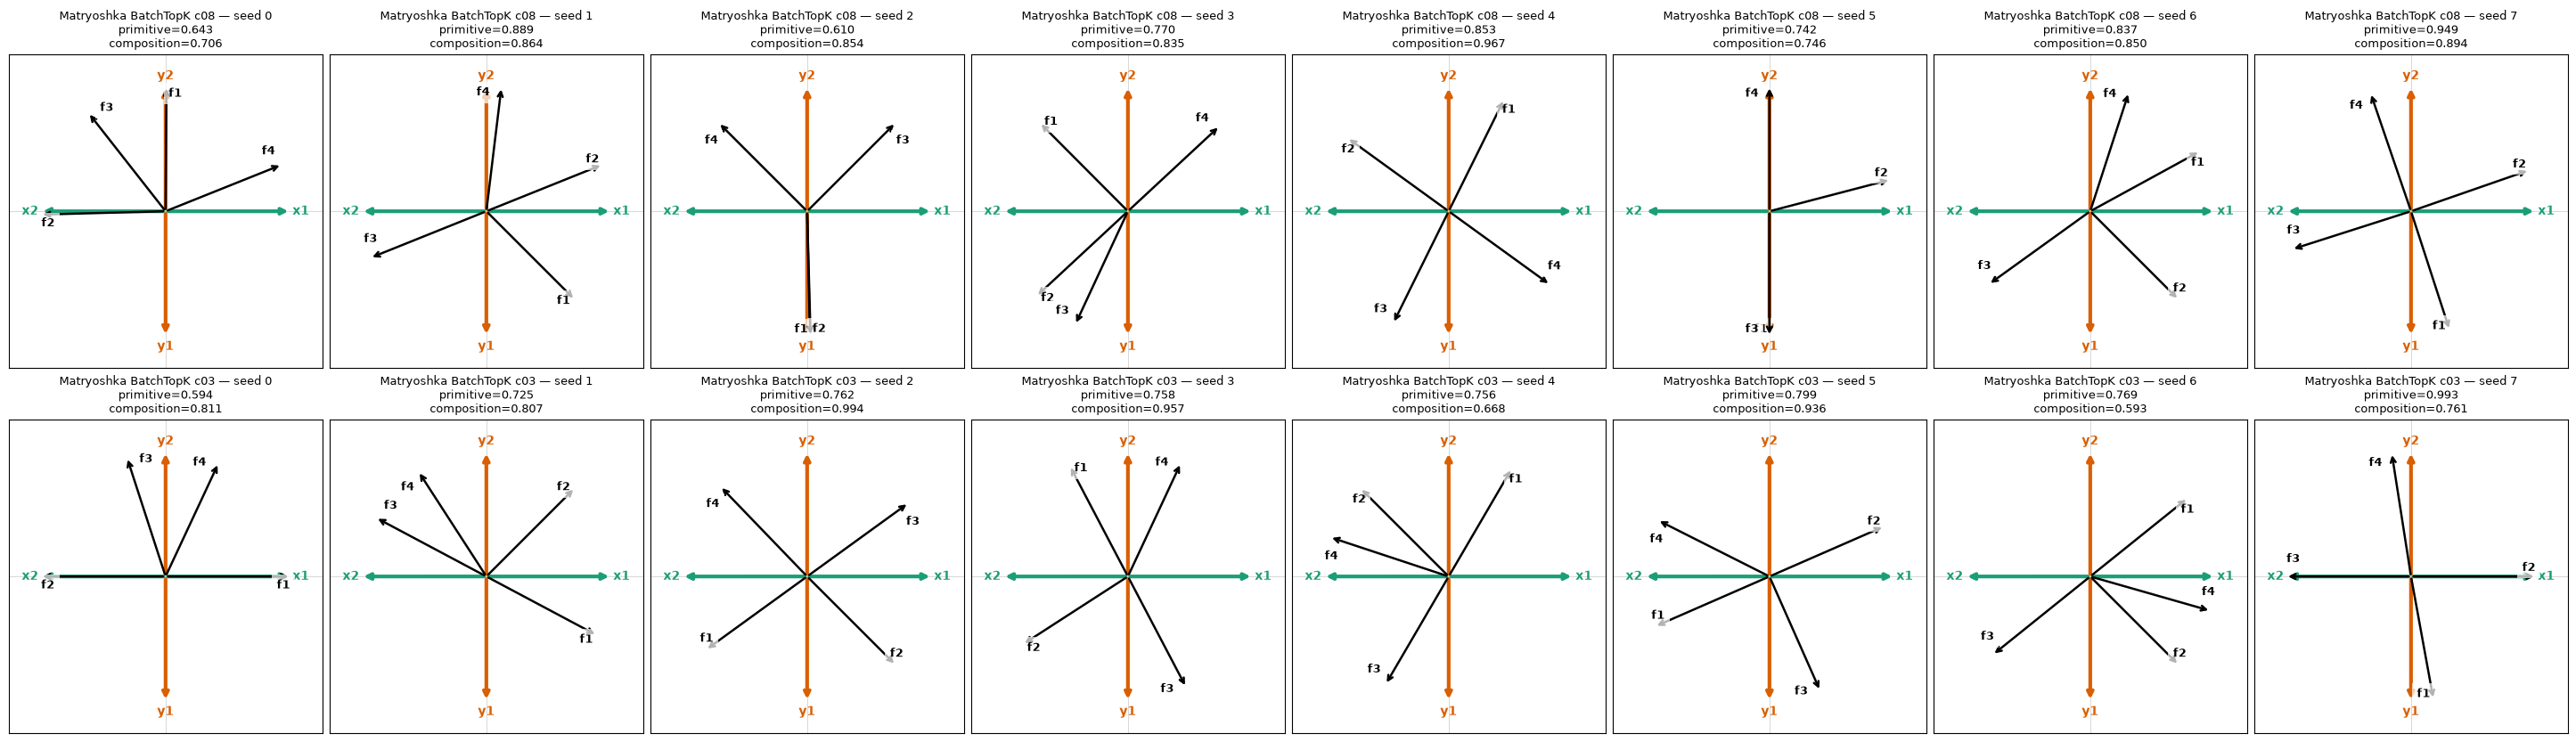

Saved artifacts/saelens_architecture_sweeps/final_128m/geometry/matching_pursuit_finalists_all_seeds.png


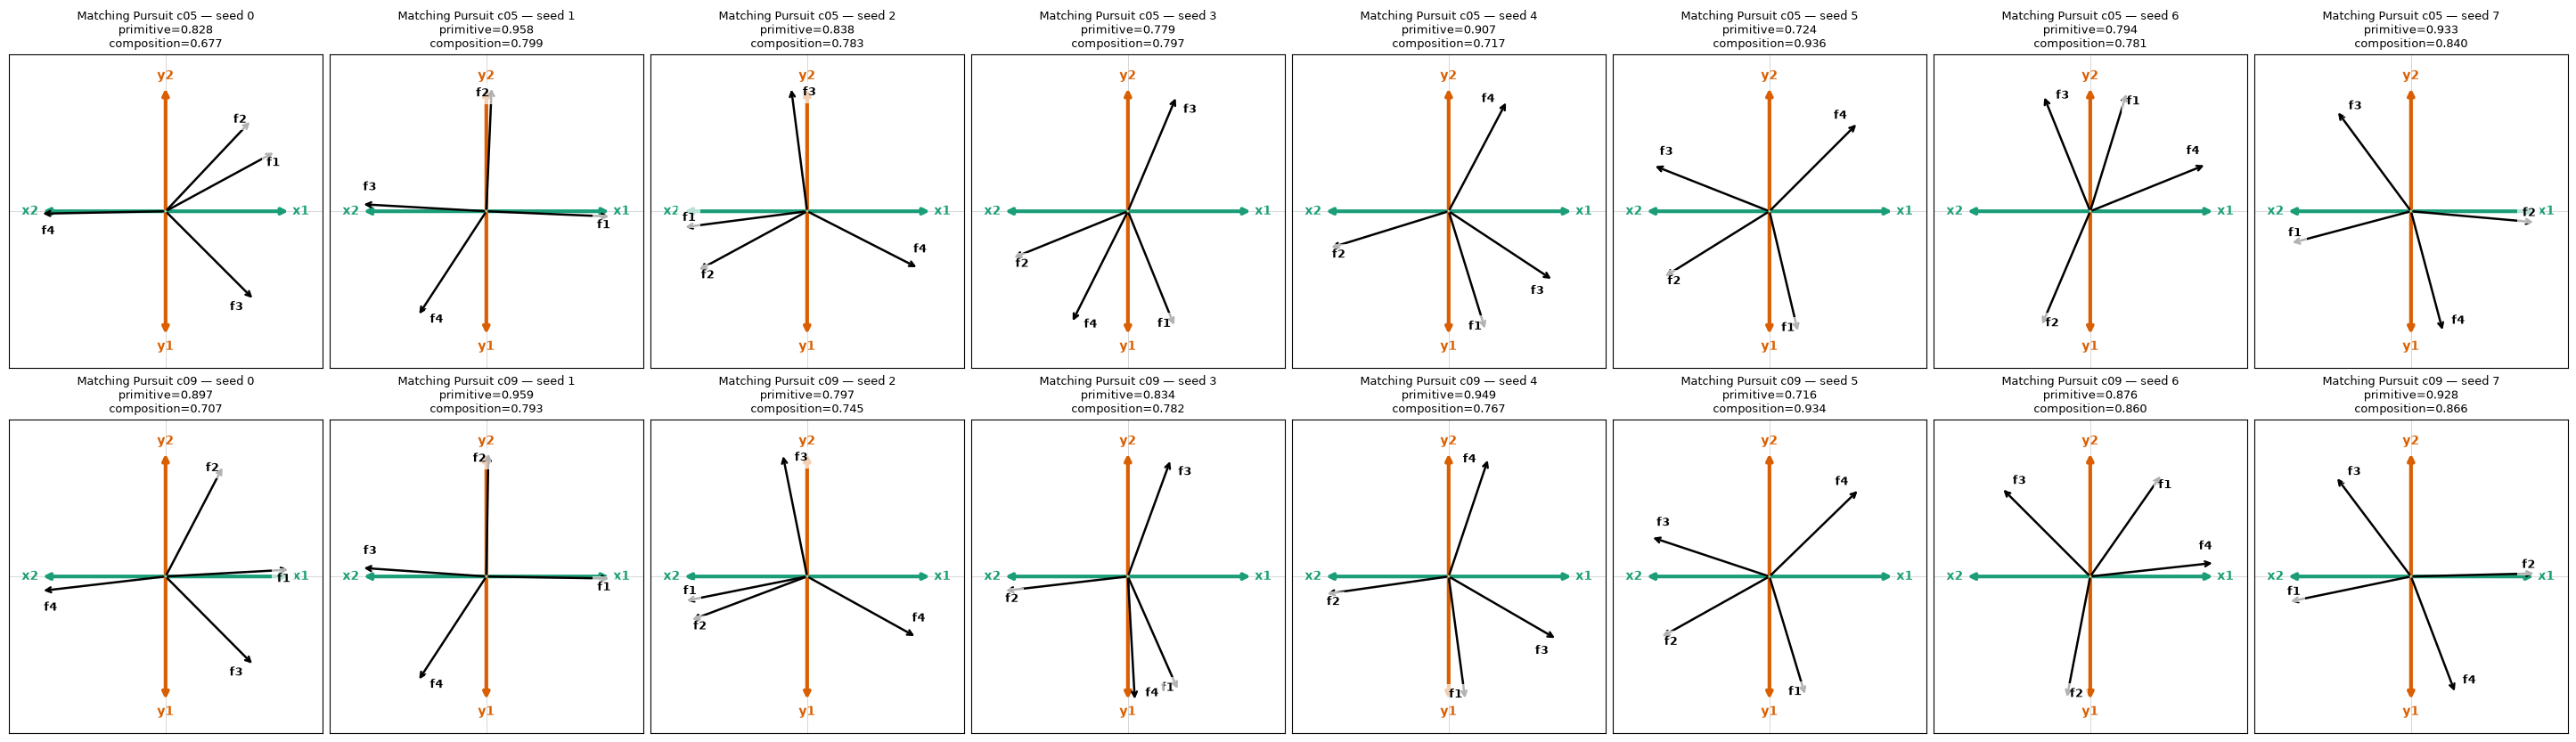

Saved artifacts/saelens_architecture_sweeps/final_128m/geometry/batchtopk_finalists_all_seeds.png


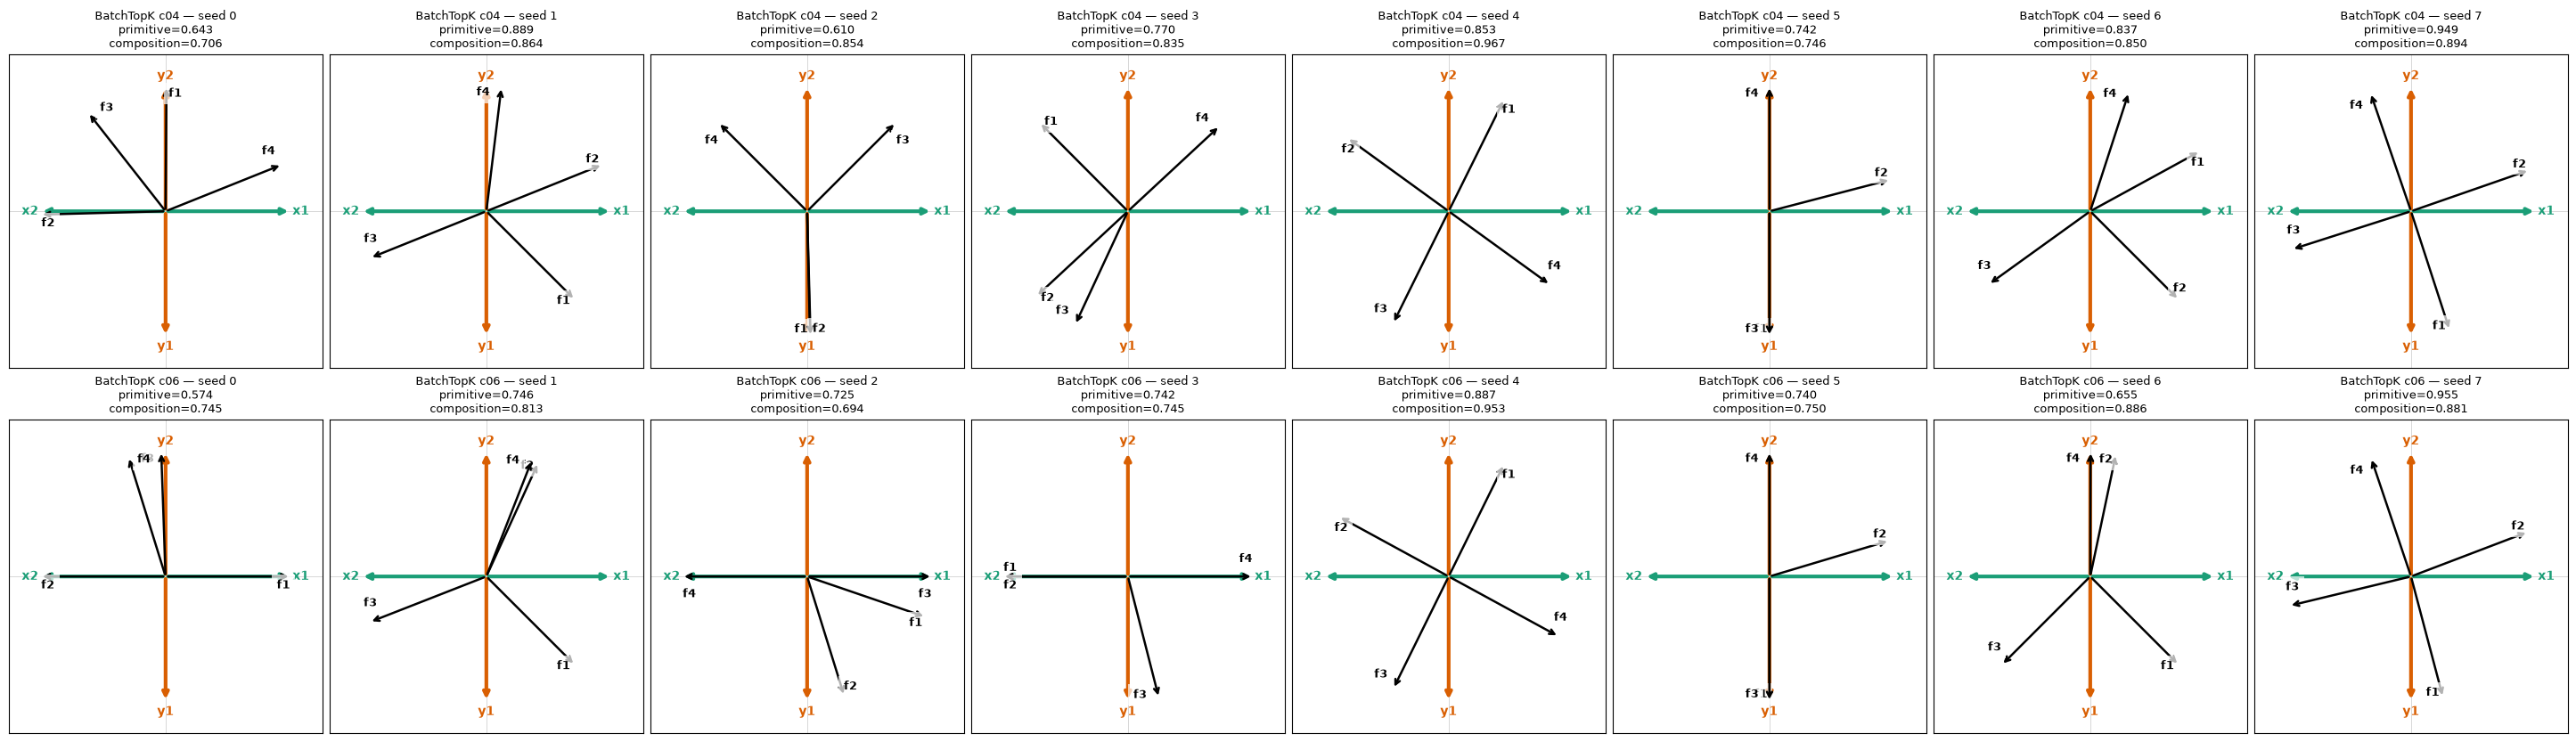

Saved artifacts/saelens_architecture_sweeps/final_128m/geometry/topk_finalists_all_seeds.png


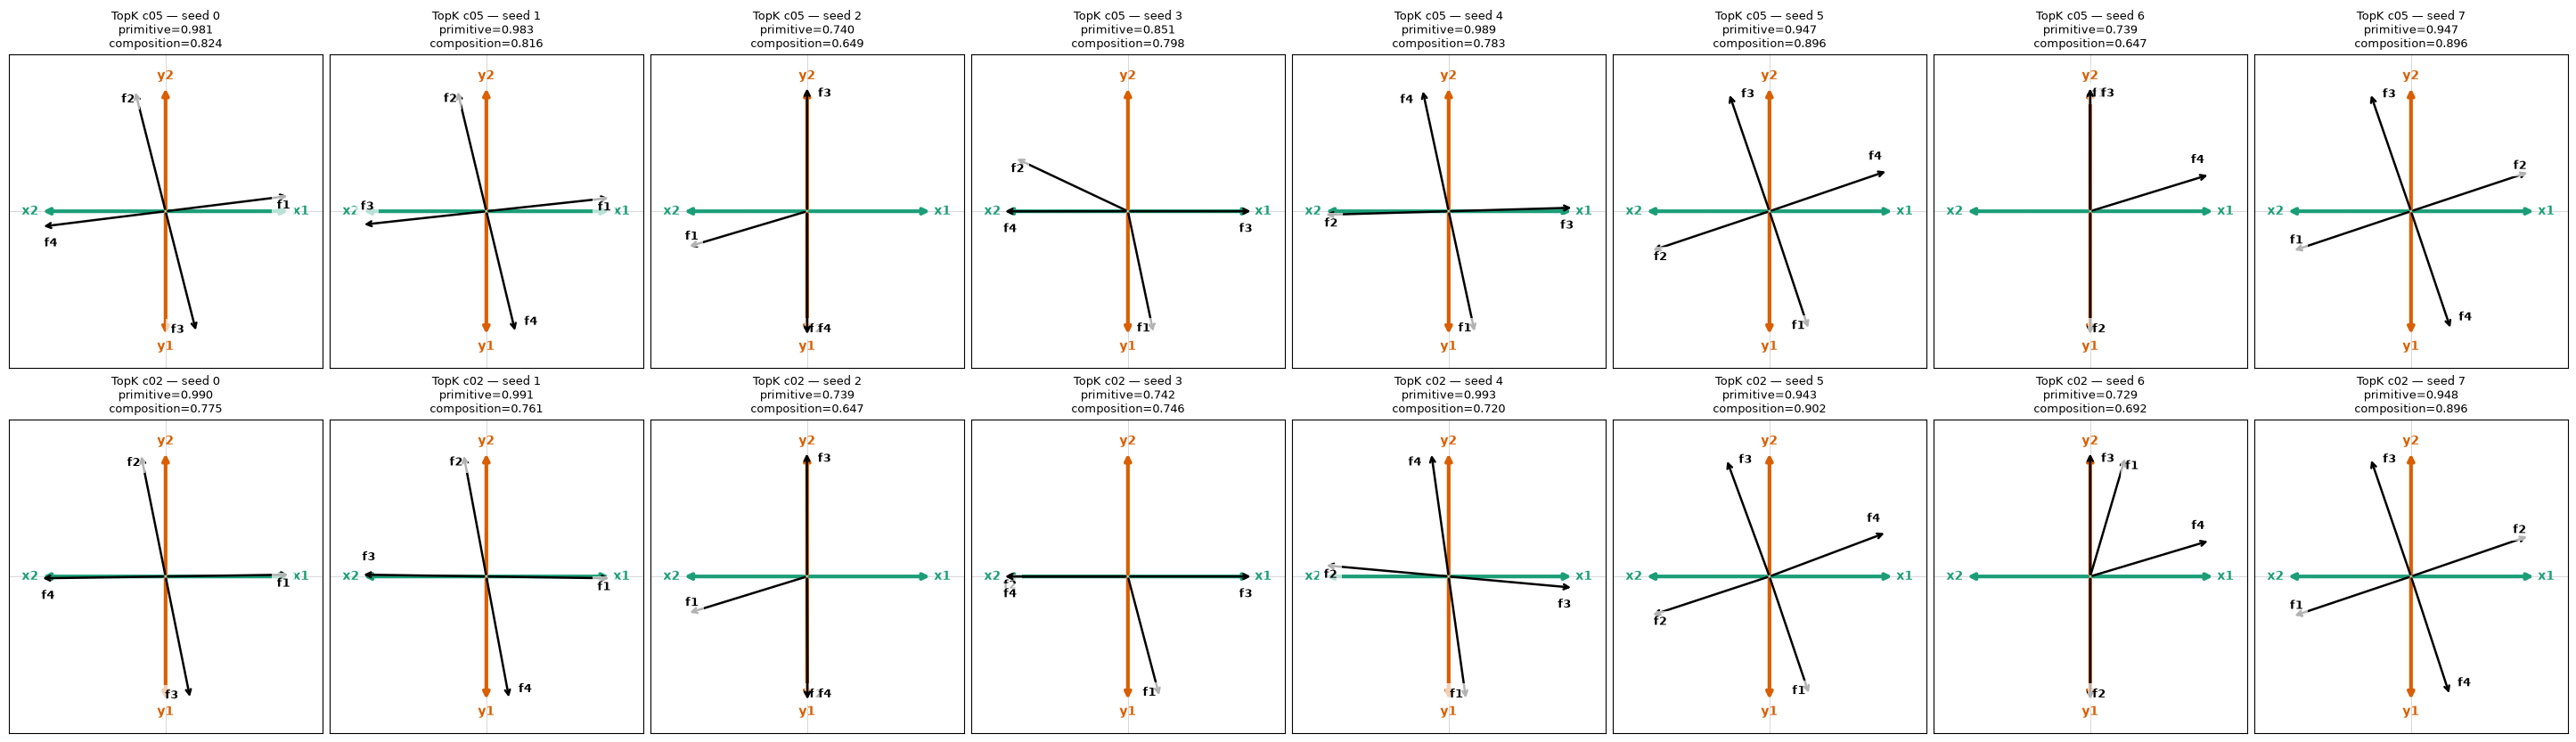

In [24]:
def plot_sweep_geometry(ax, sae, *, title, primitive, composition):
    rotated_decoders = F.normalize(
        sae.W_dec.detach().cpu(), dim=-1
    ) @ rotation
    for vector, label, color in zip(
        rotated_primitives, PRIMITIVE_LABELS, PRIMITIVE_COLORS
    ):
        draw_arrow(ax, vector, color=color, linewidth=3.0)
        ax.text(
            1.08 * float(vector[0]), 1.08 * float(vector[1]), label,
            color=color, fontsize=10, fontweight='bold',
            ha='center', va='center',
        )

    offsets = (-0.07, 0.07, -0.14, 0.14)
    zero_positions = ((0.12, 0), (0, 0.12), (-0.12, 0), (0, -0.12))
    for index, vector in enumerate(rotated_decoders, start=1):
        draw_arrow(ax, vector, color='black', linewidth=1.8)
        perpendicular = torch.tensor([-vector[1], vector[0]])
        label_position = (
            zero_positions[index - 1]
            if float(vector.norm()) < 1e-8
            else 0.94 * vector + offsets[index - 1] * perpendicular
        )
        ax.text(
            float(label_position[0]), float(label_position[1]), f'f{index}',
            color='black', fontsize=9, fontweight='bold',
            ha='center', va='center',
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.7},
        )

    ax.set_title(
        f'{title}\nprimitive={primitive:.3f}\n'
        f'composition={composition:.3f}', fontsize=9,
    )
    ax.axhline(0, color='0.82', lw=0.6)
    ax.axvline(0, color='0.82', lw=0.6)
    ax.set(xlim=(-1.25, 1.25), ylim=(-1.25, 1.25), aspect='equal')
    ax.set_xticks(())
    ax.set_yticks(())

geometry_root = SWEEP_ROOT / 'final_128m' / 'geometry'
geometry_root.mkdir(parents=True, exist_ok=True)

for method, promoted_configs in PROMOTED_CONFIGS.items():
    fig, axes = plt.subplots(
        len(promoted_configs), len(SWEEP_SEEDS),
        figsize=(3.6 * len(SWEEP_SEEDS), 4.1 * len(promoted_configs)),
        squeeze=False, constrained_layout=True,
    )
    for row, params_with_source in enumerate(promoted_configs):
        config_id = params_with_source['source_config_id']
        params = {
            key: value for key, value in params_with_source.items()
            if key != 'source_config_id'
        }
        sae_cls, _ = build_sweep_sae(method, params)
        for column, seed in enumerate(SWEEP_SEEDS):
            run_dir = (
                SWEEP_ROOT / 'final_128m' / method
                / config_id / f'seed_{seed}'
            )
            sae = load_sae_checkpoint(sae_cls, run_dir)
            metric = finalist_results[
                (finalist_results.method == method)
                & (finalist_results.config_id == config_id)
                & (finalist_results.seed == seed)
            ].iloc[0]
            title = f'{DISPLAY_NAMES[method]} {config_id} — seed {seed}'
            plot_sweep_geometry(
                axes[row, column], sae, title=title,
                primitive=metric.primitive_alignment,
                composition=metric.composition_alignment,
            )

            run_figure, run_axis = plt.subplots(figsize=(5, 5.4))
            plot_sweep_geometry(
                run_axis, sae, title=title,
                primitive=metric.primitive_alignment,
                composition=metric.composition_alignment,
            )
            run_path = geometry_root / f'{method}_{config_id}_seed_{seed}.png'
            run_figure.savefig(run_path, dpi=200, bbox_inches='tight')
            plt.close(run_figure)
            del sae

    grid_path = geometry_root / f'{method}_finalists_all_seeds.png'
    fig.savefig(grid_path, dpi=200, bbox_inches='tight')
    print('Saved', grid_path)
    plt.show()
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()

## Sweep outputs and checkpoint behavior

All new artifacts are isolated from the original baseline runs:

```text
artifacts/saelens_architecture_sweeps/
├── screening_manifest.csv
├── screen_8m/
│   ├── alignment_results.csv
│   ├── configuration_summary.csv
│   └── <method>/<config_id>/seed_<n>/
├── promoted_configs.json
└── final_128m/
    ├── alignment_results.csv
    ├── configuration_summary.csv
    ├── geometry/
    └── <method>/<config_id>/seed_<n>/
```

Each completed run directory contains `cfg.json` and `sae_weights.safetensors` and is loaded automatically on rerun. Existing baseline checkpoints under `saelens_architecture_comparison_full_128m/` are untouched.